## MLFlow dependencies and initialization

In [1]:
import mlflow
from pprint import pprint

In [2]:
# Set here the URI from your MLFLow Tracking Server
TRACKING_URI = "http://localhost:5000"
client = mlflow.MlflowClient(tracking_uri=TRACKING_URI)
mlflow.set_tracking_uri(TRACKING_URI)

### Experiment creation

In [3]:
experiment_description = (
    "Training SVM for breast cancer detection. "
    "This approach uses MLFlow with hyperparameter tuning using Optuna."
)

experiment_tags = {
    "project_name": "breast-cancer-detection",
    "model_name": "svm",
    "mlflow.note.content": experiment_description,
    "parameters_tuner": "Optuna"
}

experiment_name = "SVM_Optuna_BreastCancerDetection_PNG"

exp = client.get_experiment_by_name(experiment_name)

if exp is None:
    exp_id = client.create_experiment(
        name=experiment_name, tags=experiment_tags
    )
else:
    exp_id = exp.experiment_id
    print(f"Experiment {experiment_name} already exists. Skipping creation")

Experiment SVM_Optuna_BreastCancerDetection_PNG already exists. Skipping creation


## Training Dependencies

In [4]:
from pathlib import Path
import sys

# Force add the project root to sys.path
project_root = Path("../").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from tqdm import tqdm
import optuna
from optuna.integration.mlflow import MLflowCallback

import pyarrow.parquet as pq
import pandas as pd
import numpy as np
import os
import time
import uuid

# Import your custom modules
from training.engine import evaluate_ml
from inference.svm_explainer import SVMExplainer

C:\Users\Daniel\Documents\Personal\breast_cancer_detection\.venv\Lib\site-packages\torch\cuda\__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [5]:
# Path to the dataset file
DATA_ABS_PATH        = os.path.abspath("D:/tfm/data")
IMAGES_ABS_PATH      = os.path.abspath("D:/tfm/data/CBIS-DDSM")
PNG_ABS_PATH         = os.path.abspath("D:/tfm/data/CBIS-DDSM-PNG")
CBISDDSM_FIXED_SET   = DATA_ABS_PATH + '/meta/CBIS-DDSM-fixed.parquet'
FEATURES_OUTPUT_PATH = os.path.abspath("../models/output/features/")

In [6]:
train_df = pq.read_table("train_png.parquet").to_pandas()
val_df = pq.read_table("val_png.parquet").to_pandas()
test_df = pq.read_table("test_png.parquet").to_pandas()

In [7]:
# ===== FEATURE EXTRACTION FUNCTIONS =====

def build_route(df, images_base_path=None):
    """
    Build the full image path for each row in the DataFrame and filter out non-existent files.
    
    Args:
        df (pd.DataFrame): Input dataframe with 'image_path' column containing relative paths.
        images_base_path (str): Base path for images. Defaults to PNG_ABS_PATH if None.
        
    Returns:
        pd.DataFrame: Filtered dataframe containing only rows with existing image files.
    """
    images_path = PNG_ABS_PATH if images_base_path is None else images_base_path

    df['full_image_path'] = df['image_path'].apply(
        lambda x: os.path.normpath(os.path.join(images_path, x))
    )
    df['exists'] = df['full_image_path'].apply(os.path.exists)
    
    missing_count = (~df['exists']).sum()
    if missing_count > 0:
        print(f"[WARN] {missing_count} images not found and will be filtered out")
    
    return df[df['exists']].copy()


def extract_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Extract basic image features from the input DataFrame.

    Args:
        df (pd.DataFrame): Input dataframe with 'full_image_path' column.

    Returns:
        pd.DataFrame: DataFrame with extracted image features merged.
    """
    import pydicom
    from PIL import Image
    
    features_list = []

    for path in tqdm(df["full_image_path"], desc="Extracting features"):
        try:
            if str(path).lower().endswith(".dcm"):
                # Read DICOM
                dicom = pydicom.dcmread(path)
                img_array = dicom.pixel_array.astype(np.float32)
            else:
                # Read PNG/JPEG
                img = Image.open(path).convert("L")
                img_array = np.asarray(img, dtype=np.float32)

            if img_array.size == 0:
                raise ValueError("Empty image.")

            # Normalize to [0, 1] using global scaling (safe for both DICOM and PNG)
            img_min = np.min(img_array)
            img_max = np.max(img_array)
            img_array = (img_array - img_min) / (img_max - img_min + 1e-8)

            mean_intensity = img_array.mean()
            std_intensity = img_array.std()
            height, width = img_array.shape

            features_list.append({
                "full_image_path": path,
                "mean_intensity": mean_intensity,
                "std_intensity": std_intensity,
                "width": width,
                "height": height
            })
        except Exception as e:
            print(f"[WARN] Error with image {path}: {e}")

    features_df = pd.DataFrame(features_list)
    merged_df = df.merge(features_df, on="full_image_path", how="inner")

    return merged_df


def load_or_extract_features(df, split: str, base_dir: str, images_base_path: str):
    """
    Load feature `.parquet` if it exists, otherwise compute and save it.
    
    Args:
        df (pd.DataFrame): The base dataframe with image paths.
        split (str): One of 'train', 'val', 'test'.
        base_dir (str): Directory where feature parquet files are stored.
        images_base_path (str): Base path for images.
        
    Returns:
        pd.DataFrame: DataFrame with extracted features.
    """
    feature_path = os.path.join(base_dir, f"{split}_features.parquet")
    
    if os.path.exists(feature_path):
        print(f"[INFO] Loading precomputed features for '{split}' from: {feature_path}")
        return pd.read_parquet(feature_path)
    
    print(f"[INFO] Extracting features for '{split}' (not cached)...")
    df = build_route(df, images_base_path=images_base_path)
    df = extract_features(df)
    df.to_parquet(feature_path, index=False)
    print(f"[INFO] Saved features to {feature_path}")
    
    return df

In [8]:
len(set(train_df["patient_id"]).intersection(val_df["patient_id"]))

0

In [9]:
assert set(train_df["patient_id"]).intersection(set(val_df["patient_id"])) == set()
assert set(train_df["patient_id"]).intersection(set(test_df["patient_id"])) == set()
assert set(val_df["patient_id"]).intersection(set(test_df["patient_id"])) == set()

In [10]:
# Run this to get the key info I need:

print("=== DATASET SIZE ===")
print(f"Train: {len(train_df)}")
print(f"Val: {len(val_df)}")
print(f"Test: {len(test_df)}")

print("\n=== CLASS DISTRIBUTION ===")
print("Train:")
print(train_df["pathology"].value_counts())
print("\nVal:")
print(val_df["pathology"].value_counts())
print("\nTest:")
print(test_df["pathology"].value_counts())

print("\n=== UNIQUE PATIENTS ===")
print(f"Train patients: {train_df['patient_id'].nunique()}")
print(f"Val patients: {val_df['patient_id'].nunique()}")
print(f"Test patients: {test_df['patient_id'].nunique()}")

# Critical sanity check:
print("\n=== PATIENT LEAKAGE CHECK ===")
train_patients = set(train_df['patient_id'])
val_patients = set(val_df['patient_id'])
test_patients = set(test_df['patient_id'])
print(f"Train ∩ Val: {len(train_patients & val_patients)} (should be 0)")
print(f"Train ∩ Test: {len(train_patients & test_patients)} (should be 0)")
print(f"Val ∩ Test: {len(val_patients & test_patients)} (should be 0)")

=== DATASET SIZE ===
Train: 2315
Val: 559
Test: 694

=== CLASS DISTRIBUTION ===
Train:
pathology
MALIGNANT                  970
BENIGN                     882
BENIGN_WITHOUT_CALLBACK    463
Name: count, dtype: int64

Val:
pathology
BENIGN                     237
MALIGNANT                  223
BENIGN_WITHOUT_CALLBACK     99
Name: count, dtype: int64

Test:
pathology
BENIGN                     310
MALIGNANT                  264
BENIGN_WITHOUT_CALLBACK    120
Name: count, dtype: int64

=== UNIQUE PATIENTS ===
Train patients: 1001
Val patients: 251
Test patients: 314

=== PATIENT LEAKAGE CHECK ===
Train ∩ Val: 0 (should be 0)
Train ∩ Test: 0 (should be 0)
Val ∩ Test: 0 (should be 0)


### Set hyperparameters

In [11]:
# Correlation id for experiment tracking
correlation_id = uuid.uuid4()
corr_id = str(correlation_id)[:6]

### Set DataLoaders

In [12]:
# ===== FEATURE EXTRACTION =====
print("\n" + "="*60)
print("FEATURE EXTRACTION")
print("="*60)

# Extract or load features for all splits
train_df = load_or_extract_features(train_df, "train", FEATURES_OUTPUT_PATH, PNG_ABS_PATH)
val_df   = load_or_extract_features(val_df, "val", FEATURES_OUTPUT_PATH, PNG_ABS_PATH)
test_df  = load_or_extract_features(test_df, "test", FEATURES_OUTPUT_PATH, PNG_ABS_PATH)

print(f"\n[INFO] Train set: {len(train_df)} samples with features")
print(f"[INFO] Val set: {len(val_df)} samples with features")
print(f"[INFO] Test set: {len(test_df)} samples with features")

# Define feature columns
FEATURE_COLS = ['mean_intensity','std_intensity','width','height','assessment','breast_density','subtlety']

print(f"\n[INFO] Using {len(FEATURE_COLS)} features: {FEATURE_COLS}")

# Extract X and y for each split
X_train = train_df[FEATURE_COLS].values
y_train = train_df['pathology'].values

X_val = val_df[FEATURE_COLS].values
y_val = val_df['pathology'].values

X_test = test_df[FEATURE_COLS].values
y_test = test_df['pathology'].values

# Optional: extract view info if available for per-view metrics
view_train = train_df['image_view'].values if 'image_view' in train_df.columns else None
view_val = val_df['image_view'].values if 'image_view' in val_df.columns else None
view_test = test_df['image_view'].values if 'image_view' in test_df.columns else None

print("\n[INFO] Feature extraction complete!")
print(f"  X_train shape: {X_train.shape}")
print(f"  X_val shape: {X_val.shape}")
print(f"  X_test shape: {X_test.shape}")

# MLFlow datasets (keep for tracking)
ml_train_dataset = mlflow.data.from_pandas(train_df, name="cbis_ddsm_train")
ml_val_dataset = mlflow.data.from_pandas(val_df, name="cbis_ddsm_val")
ml_test_dataset = mlflow.data.from_pandas(test_df, name="cbis_ddsm_test")


FEATURE EXTRACTION
[INFO] Loading precomputed features for 'train' from: C:\Users\Daniel\Documents\Personal\breast_cancer_detection\models\output\features\train_features.parquet
[INFO] Loading precomputed features for 'val' from: C:\Users\Daniel\Documents\Personal\breast_cancer_detection\models\output\features\val_features.parquet
[INFO] Loading precomputed features for 'test' from: C:\Users\Daniel\Documents\Personal\breast_cancer_detection\models\output\features\test_features.parquet

[INFO] Train set: 3381 samples with features
[INFO] Val set: 781 samples with features
[INFO] Test set: 918 samples with features

[INFO] Using 7 features: ['mean_intensity', 'std_intensity', 'width', 'height', 'assessment', 'breast_density', 'subtlety']

[INFO] Feature extraction complete!
  X_train shape: (3381, 7)
  X_val shape: (781, 7)
  X_test shape: (918, 7)


## Using my stuff for training

In [13]:
# ============================================================================
# SVM PREDICTOR CLASS FOR MLFLOW SERVING
# ============================================================================

import mlflow.pyfunc
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler


class SVMImagePredictor(mlflow.pyfunc.PythonModel):
    """
    MLflow PyFunc flavor for SVM breast cancer classification.
    """
    
    def load_context(self, context):
        """
        Called once when model is loaded for serving.
        """
        import joblib
        
        # Load the SVM model and scaler from MLflow artifacts
        self.model = joblib.load(context.artifacts["model_path"])
        self.scaler = joblib.load(context.artifacts["scaler_path"])
        
        # Class names for interpretable output
        self.class_names = ['benign', 'benign_without_callback', 'malignant']
    
    def predict(self, context, model_input):
        """
        Accept feature vectors.
        
        Args:
            context: MLflow context
            model_input: pandas DataFrame with feature columns
        
        Returns:
            list of dicts with predictions
        """
        predictions = []
        
        # Scale features
        X_scaled = self.scaler.transform(model_input)
        
        # Get predictions and probabilities
        y_pred = self.model.predict(X_scaled)
        y_prob = self.model.predict_proba(X_scaled)
        
        for i in range(len(y_pred)):
            predicted_class = int(y_pred[i])
            predictions.append({
                'predicted_class': predicted_class,
                'predicted_class_name': self.class_names[predicted_class],
                'confidence': float(y_prob[i][predicted_class]),
                'probabilities': {
                    'benign': float(y_prob[i][0]),
                    'benign_without_callback': float(y_prob[i][1]),
                    'malignant': float(y_prob[i][2])
                }
            })
        
        return predictions

C:\Users\Daniel\Documents\Personal\breast_cancer_detection\.venv\Lib\site-packages\mlflow\pyfunc\utils\data_validation.py:186: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


In [14]:
import uuid
import optuna
import mlflow
import joblib
import tempfile
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)

mlflow.set_experiment(experiment_name)

NUM_STUDIES = 2
N_TRIALS_PER_STUDY = 10

# Track the global best across ALL studies and trials
global_best_malignant_recall = 0.0
global_best_run_id = None
corr_id = str(correlation_id)[:6]

# Single registered model name for all versions
REGISTERED_MODEL_NAME = "svm-breast-cancer"

# Class names
class_names = ['BENIGN', 'BENIGN_WITHOUT_CALLBACK', 'MALIGNANT']

for study_number in range(NUM_STUDIES):
    study_name = f"svm_study_{study_number}_{corr_id}"
    
    # Start a parent MLflow run for the study
    with mlflow.start_run(run_name=f"parent_{study_name}", nested=False) as parent_run:
        parent_run_id = parent_run.info.run_id
        
        mlflow.set_tag("study_name", study_name)
        mlflow.set_tag("correlation_id", corr_id)
        mlflow.log_param("study_number", study_number)

        study = optuna.create_study(
            study_name=study_name,
            direction="maximize",
            pruner=optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=5),
            sampler=optuna.samplers.TPESampler(seed=42)
        )

        def objective(trial):
            global global_best_malignant_recall, global_best_run_id
        
            # ===== HYPERPARAMETERS (clean, realistic search space) =====
            C = trial.suggest_float("C", 0.1, 10, log=True)
            kernel = trial.suggest_categorical("kernel", ["linear", "rbf"])
            gamma = trial.suggest_categorical("gamma", ["scale", "auto"])
            class_weight = trial.suggest_categorical("class_weight", [None, "balanced"])
        
            # ===== START MLFLOW TRIAL =====
            with mlflow.start_run(run_name=f"svm_trial_{trial.number}", nested=True) as trial_run:
                trial_run_id = trial_run.info.run_id
        
                mlflow.log_params({
                    "C": C,
                    "kernel": kernel,
                    "gamma": gamma,
                    "class_weight": class_weight
                })
        
                # ===== PREPROCESS =====
                scaler = StandardScaler()
                X_scaled = scaler.fit_transform(X_train)

                # ===== CROSS VALIDATION =====
                skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
                malignant_recalls = []

                # OJO: aquí usamos y_train_enc en lugar de y_train
                for train_idx, val_idx in skf.split(X_scaled, y_train_enc):
                    X_tr, X_va = X_scaled[train_idx], X_scaled[val_idx]
                    y_tr, y_va = y_train_enc[train_idx], y_train_enc[val_idx]

                    model = SVC(
                        C=C,
                        kernel=kernel,
                        gamma=gamma,
                        class_weight=class_weight,
                        probability=True,
                        random_state=42
                    )

                    model.fit(X_tr, y_tr)

                    # Predict
                    y_pred = model.predict(X_va)
                    report = classification_report(
                        y_va, y_pred,
                        output_dict=True,
                        zero_division=0
                    )

                    malignant_recall = report['2']['recall']
                    malignant_recalls.append(malignant_recall)
        
                # ===== FINAL CV METRIC =====
                cv_rec = float(np.mean(malignant_recalls))
                mlflow.log_metric("cv_malignant_recall", cv_rec)
        
                # ===== CHECK IF BEST MODEL =====
                if cv_rec > global_best_malignant_recall:
                    global_best_malignant_recall = cv_rec
                    global_best_run_id = trial_run_id
        
                    print(f"NEW BEST SVM! malignant recall={cv_rec:.4f}")
        
                    with tempfile.TemporaryDirectory() as tmpdir:
                        model_path = os.path.join(tmpdir, "model.pkl")
                        scaler_path = os.path.join(tmpdir, "scaler.pkl")
        
                        joblib.dump(model, model_path)
                        joblib.dump(scaler, scaler_path)
        
                        # Log native sklearn model
                        mlflow.sklearn.log_model(
                            model,
                            artifact_path="sklearn_model",
                        )
        
                        mlflow.log_artifact(scaler_path, "artifacts")
        
                        # Log PyFunc image predictor model
                        mlflow.pyfunc.log_model(
                            artifact_path="svm_predictor",
                            python_model=SVMImagePredictor(),
                            artifacts={
                                "model_path": model_path,
                                "scaler_path": scaler_path,
                            }
                        )
        
                    # Register best version
                    mlflow.register_model(
                        model_uri=f"runs:/{trial_run_id}/svm_predictor",
                        name=REGISTERED_MODEL_NAME
                    )
        
                return cv_rec

        # Run the optimization
        study.optimize(objective, n_trials=N_TRIALS_PER_STUDY, show_progress_bar=True)

        # Log study summary
        mlflow.log_param("best_trial_number", study.best_trial.number)
        mlflow.log_param("best_malignant_recall", study.best_value)
        mlflow.log_params({f"best_{k}": v for k, v in study.best_params.items()})
        
        print(f"\nStudy {study_number} complete. Best malignant recall: {study.best_value:.4f}")

print(f"\n{'='*80}")
print(f"All studies completed.")
print(f"Global best malignant recall: {global_best_malignant_recall:.4f}")
print(f"Global best run ID: {global_best_run_id}")
print(f"Registered model: {REGISTERED_MODEL_NAME}")
print(f"{'='*80}")

[I 2025-11-15 18:45:15,373] A new study created in memory with name: svm_study_0_e246bb


  0%|          | 0/10 [00:00<?, ?it/s]

2025/11/15 18:45:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


NEW BEST SVM! malignant recall=0.7714


2025/11/15 18:45:18 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2025/11/15 18:45:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2025/11/15 18:45:21 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Registered model 'svm-breast-cancer' already exists. Creating a new version of this model...
2025/11/15 18:45:22 WARNING mlflow.tracking._model_registry.fluent: Run with id 2da8465ab9804143af0e835b2ce6b435 has no artifacts at artifact path 'svm_predictor', registering model based on models:/m-a3df97c9fa794bd28462dcff14f8de92 instead
2025/11/15 18:45:22 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: svm-breast-cancer, version 11
Created version '11' of model 'svm-breast-cancer'.


🏃 View run svm_trial_0 at: http://localhost:5000/#/experiments/21/runs/2da8465ab9804143af0e835b2ce6b435
🧪 View experiment at: http://localhost:5000/#/experiments/21
[I 2025-11-15 18:45:22,888] Trial 0 finished with value: 0.7713630421865716 and parameters: {'C': 0.5611516415334505, 'kernel': 'linear', 'gamma': 'scale', 'class_weight': None}. Best is trial 0 with value: 0.7713630421865716.
🏃 View run svm_trial_1 at: http://localhost:5000/#/experiments/21/runs/cd8b719480734ed9a519325e683ad89b
🧪 View experiment at: http://localhost:5000/#/experiments/21
[I 2025-11-15 18:45:23,832] Trial 1 finished with value: 0.7188995840760547 and parameters: {'C': 5.3994844097874335, 'kernel': 'rbf', 'gamma': 'auto', 'class_weight': None}. Best is trial 0 with value: 0.7713630421865716.
🏃 View run svm_trial_2 at: http://localhost:5000/#/experiments/21/runs/4ba874fffd8d4d5dafb855fcab439f0e
🧪 View experiment at: http://localhost:5000/#/experiments/21
[I 2025-11-15 18:45:24,964] Trial 2 finished with value

[I 2025-11-15 18:45:32,591] A new study created in memory with name: svm_study_1_e246bb


  0%|          | 0/10 [00:00<?, ?it/s]

🏃 View run svm_trial_0 at: http://localhost:5000/#/experiments/21/runs/8ed57960e299427fb6b33184a303ccf1
🧪 View experiment at: http://localhost:5000/#/experiments/21
[I 2025-11-15 18:45:33,444] Trial 0 finished with value: 0.7713630421865716 and parameters: {'C': 0.5611516415334505, 'kernel': 'linear', 'gamma': 'scale', 'class_weight': None}. Best is trial 0 with value: 0.7713630421865716.
🏃 View run svm_trial_1 at: http://localhost:5000/#/experiments/21/runs/fc398ce5cc2849438acecee6a5ff358c
🧪 View experiment at: http://localhost:5000/#/experiments/21
[I 2025-11-15 18:45:34,391] Trial 1 finished with value: 0.7188995840760547 and parameters: {'C': 5.3994844097874335, 'kernel': 'rbf', 'gamma': 'auto', 'class_weight': None}. Best is trial 0 with value: 0.7713630421865716.
🏃 View run svm_trial_2 at: http://localhost:5000/#/experiments/21/runs/b15c616bed65444b842876a181d0c72e
🧪 View experiment at: http://localhost:5000/#/experiments/21
[I 2025-11-15 18:45:35,527] Trial 2 finished with value

In [17]:
import mlflow
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
import joblib

# ===== LOAD BEST MODEL =====
print("\n" + "="*60)
print("LOADING BEST MODEL FOR TEST EVALUATION")
print("="*60)
print(f"\nGlobal best malignant recall: {global_best_malignant_recall:.4f}")
print(f"Global best run ID: {global_best_run_id}")

# Load the best model from MLflow
model_uri = f"runs:/{global_best_run_id}/sklearn_model"
model = mlflow.sklearn.load_model(model_uri)

# Load the scaler
client = mlflow.tracking.MlflowClient()
scaler_path = client.download_artifacts(global_best_run_id, "artifacts/scaler.pkl")
scaler = joblib.load(scaler_path)

# Get the best run's parameters
run = client.get_run(global_best_run_id)
best_params = run.data.params

print("\nBest hyperparameters used:")
for key in ['C', 'kernel', 'gamma', 'degree', 'class_weight']:
    if key in best_params:
        print(f"  {key}: {best_params[key]}")

# ===== PREPARE TEST DATASET =====
print("\n" + "="*60)
print("PREPARING TEST DATASET")
print("="*60)

X_test_scaled = scaler.transform(X_test)
y_test_enc = le.transform(y_test)

# ===== EVALUATE ON TEST SET =====
print("\n" + "="*60)
print("EVALUATING ON TEST SET")
print("="*60)

test_acc, test_loss, test_recall, test_precision, test_f1, test_auc, \
test_views, test_view_predictions, test_class_metrics = evaluate_ml(
    model, X_test_scaled, y_test_enc,
    view_info=None,
    class_names=class_names
)

# Extract malignant recall
test_malignant_recall = test_class_metrics.get('MALIGNANT', {}).get('recall', 0)

# ===== DISPLAY RESULTS =====
print("\n" + "="*60)
print("TEST SET RESULTS")
print("="*60)
print(f"\nOverall Metrics:")
print(f"  Accuracy:  {test_acc:.4f}")
print(f"  Recall:    {test_recall:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  F1 Score:  {test_f1:.4f}")
print(f"  AUC:       {test_auc:.4f}" if test_auc else "  AUC:       N/A")

print(f"\nCRITICAL METRIC:")
print(f"  Malignant (Class 2) Recall: {test_malignant_recall:.4f}")

print("\nPer-Class Metrics:")
for class_name, metrics in test_class_metrics.items():
    print(f"\n  {class_name}:")
    for metric_name, value in metrics.items():
        print(f"    {metric_name}: {value:.4f}")

# ===== LOG TEST RESULTS TO MLFLOW =====
print("\n" + "="*60)
print("LOGGING TEST RESULTS TO MLFLOW")
print("="*60)

mlflow.set_experiment(experiment_name)
with mlflow.start_run(run_name=f"test_evaluation_{corr_id}") as test_run:
    mlflow.set_tag("evaluation_type", "test_set")
    mlflow.set_tag("best_model_run_id", global_best_run_id)
    mlflow.set_tag("correlation_id", corr_id)
    
    # Log test metrics
    mlflow.log_metric("test_accuracy", test_acc)
    mlflow.log_metric("test_recall", test_recall)
    mlflow.log_metric("test_precision", test_precision)
    mlflow.log_metric("test_f1", test_f1)
    if test_auc:
        mlflow.log_metric("test_auc", test_auc)
    mlflow.log_metric("test_malignant_recall", test_malignant_recall)
    
    # Log per-class metrics
    for class_name, metrics in test_class_metrics.items():
        for metric_name, metric_value in metrics.items():
            mlflow.log_metric(f"test_{class_name}_{metric_name}", metric_value)
    
    # ===== CREATE VISUALIZATIONS =====
    
    # 1. Confusion Matrix
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test_enc, y_pred)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"test_confusion_matrix_{corr_id}.png", dpi=300, bbox_inches='tight')
    mlflow.log_artifact(f"test_confusion_matrix_{corr_id}.png")
    plt.close()
    
    # 2. Performance Comparison: Validation vs Test
    comparison_data = {
        'Metric': ['Accuracy', 'Recall', 'Precision', 'F1', 'Malignant Recall'],
        'Validation': [
            float(run.data.metrics.get('val_accuracy', 0)),
            float(run.data.metrics.get('val_recall', 0)),
            float(run.data.metrics.get('val_precision', 0)),
            float(run.data.metrics.get('val_f1', 0)),
            float(run.data.metrics.get('val_malignant_recall', global_best_malignant_recall))
        ],
        'Test': [test_acc, test_recall, test_precision, test_f1, test_malignant_recall]
    }
    
    fig, ax = plt.subplots(figsize=(10, 6))
    x = np.arange(len(comparison_data['Metric']))
    width = 0.35
    
    ax.bar(x - width/2, comparison_data['Validation'], width, label='Validation', alpha=0.8)
    ax.bar(x + width/2, comparison_data['Test'], width, label='Test', alpha=0.8)
    
    ax.set_xlabel('Metrics', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Model Performance: Validation vs Test', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(comparison_data['Metric'], rotation=45, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    
    plt.savefig(f"test_vs_validation_performance_{corr_id}.png", dpi=300, bbox_inches='tight')
    mlflow.log_artifact(f"test_vs_validation_performance_{corr_id}.png")
    plt.close()
    
    # 3. Per-Class Performance
    class_names_list = list(test_class_metrics.keys())
    recalls = [test_class_metrics[c].get('recall', 0) for c in class_names_list]
    precisions = [test_class_metrics[c].get('precision', 0) for c in class_names_list]
    f1_scores = [test_class_metrics[c].get('f1', 0) for c in class_names_list]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    x = np.arange(len(class_names_list))
    width = 0.25
    
    ax.bar(x - width, recalls, width, label='Recall', alpha=0.8)
    ax.bar(x, precisions, width, label='Precision', alpha=0.8)
    ax.bar(x + width, f1_scores, width, label='F1 Score', alpha=0.8)
    
    ax.set_xlabel('Class', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Per-Class Performance on Test Set', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(class_names_list, rotation=45, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim([0, 1.1])
    plt.tight_layout()
    
    plt.savefig(f"test_per_class_performance_{corr_id}.png", dpi=300, bbox_inches='tight')
    mlflow.log_artifact(f"test_per_class_performance_{corr_id}.png")
    plt.close()
    
    print("Test results and visualizations logged to MLflow")

print("\n" + "="*60)
print("TEST EVALUATION COMPLETE")
print("="*60)
print(f"\nFinal Test Malignant Recall: {test_malignant_recall:.4f}")
print(f"Registered Model: {REGISTERED_MODEL_NAME}")
print("="*60)


LOADING BEST MODEL FOR TEST EVALUATION

Global best malignant recall: 0.7714
Global best run ID: 2da8465ab9804143af0e835b2ce6b435



Best hyperparameters used:
  C: 0.5611516415334505
  kernel: linear
  gamma: scale
  class_weight: None

PREPARING TEST DATASET

EVALUATING ON TEST SET

TEST SET RESULTS

Overall Metrics:
  Accuracy:  0.6340
  Recall:    0.6603
  Precision: 0.6282
  F1 Score:  0.6278
  AUC:       0.8430

CRITICAL METRIC:
  Malignant (Class 2) Recall: 0.7372

Per-Class Metrics:

  BENIGN:
    recall: 0.3276
    precision: 0.5610
    f1: 0.4137
    accuracy: 0.6449
    auc_roc: 0.7315

  BENIGN_WITHOUT_CALLBACK:
    recall: 0.9161
    precision: 0.7583
    f1: 0.8298
    accuracy: 0.8878
    auc_roc: 0.9486

  MALIGNANT:
    recall: 0.7372
    precision: 0.5654
    f1: 0.6400
    accuracy: 0.7353
    auc_roc: 0.8488

LOGGING TEST RESULTS TO MLFLOW
Test results and visualizations logged to MLflow
🏃 View run test_evaluation_e246bb at: http://localhost:5000/#/experiments/21/runs/4c2b287c76134c4ba40e6494f5358604
🧪 View experiment at: http://localhost:5000/#/experiments/21

TEST EVALUATION COMPLETE

Final Te


GENERATING SHAP EXPLANATIONS

SHAP para clase 0 → BENIGN


C:\Users\Daniel\Documents\Personal\breast_cancer_detection\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


  0%|          | 0/10 [00:00<?, ?it/s]

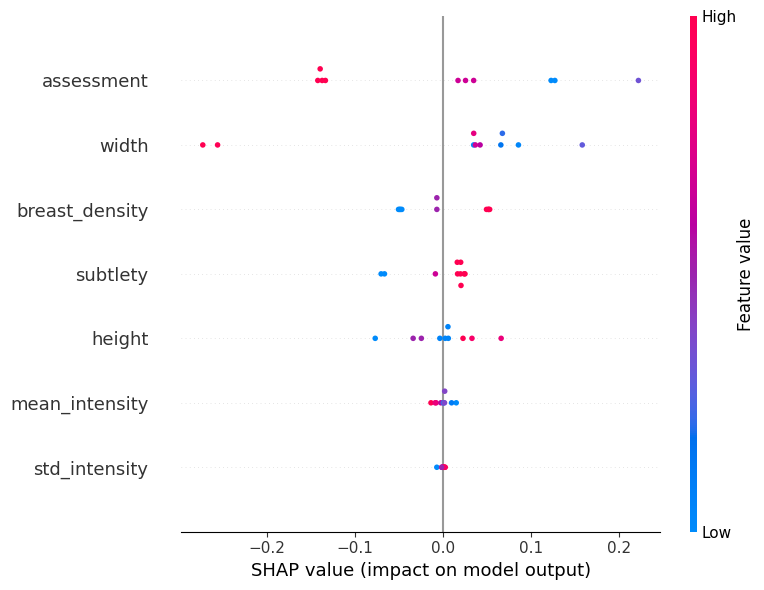


SHAP para clase 1 → BENIGN_WITHOUT_CALLBACK


  0%|          | 0/10 [00:00<?, ?it/s]

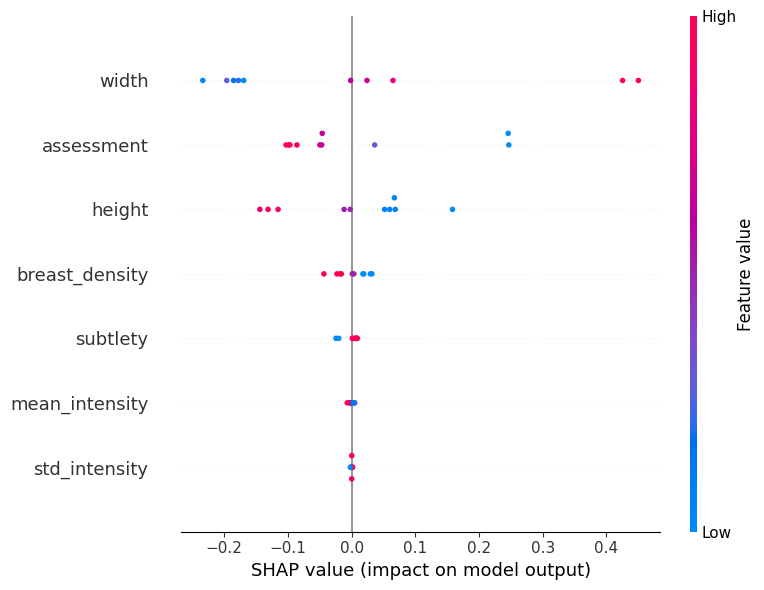


SHAP para clase 2 → MALIGNANT


  0%|          | 0/10 [00:00<?, ?it/s]

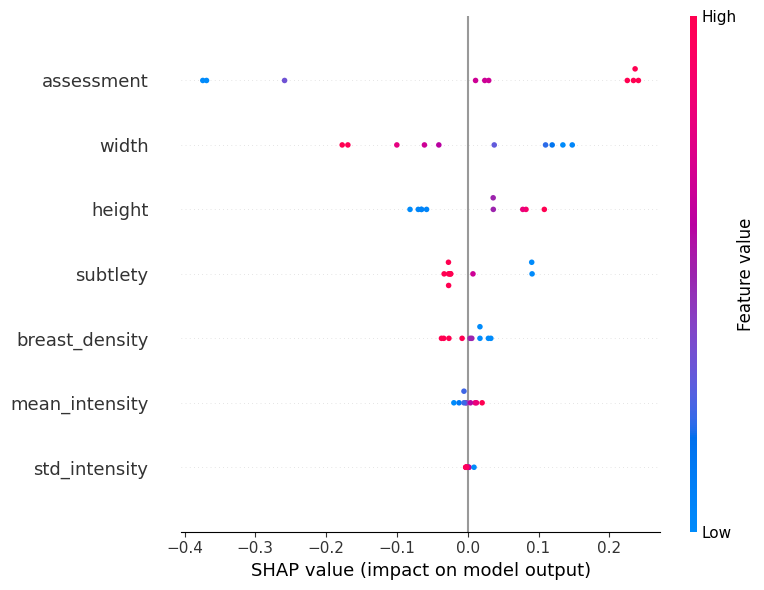

SHAP explanations generated and plotted


In [18]:
# ===== SHAP EXPLAINABILITY =====
print("\n" + "="*60)
print("GENERATING SHAP EXPLANATIONS")
print("="*60)

# Create explainer
explainer = SVMExplainer(
    model=model,
    scaler=scaler,
    feature_cols=FEATURE_COLS,
    label_list=class_names
)

# Select a sample for explanation (e.g., first 10 test samples)
X_sample = pd.DataFrame(X_test[:10])

# Generate SHAP explanations
shap_values = explainer.explain(X_sample)

print("SHAP explanations generated and plotted")
print("="*60)


FEATURE STATISTICS


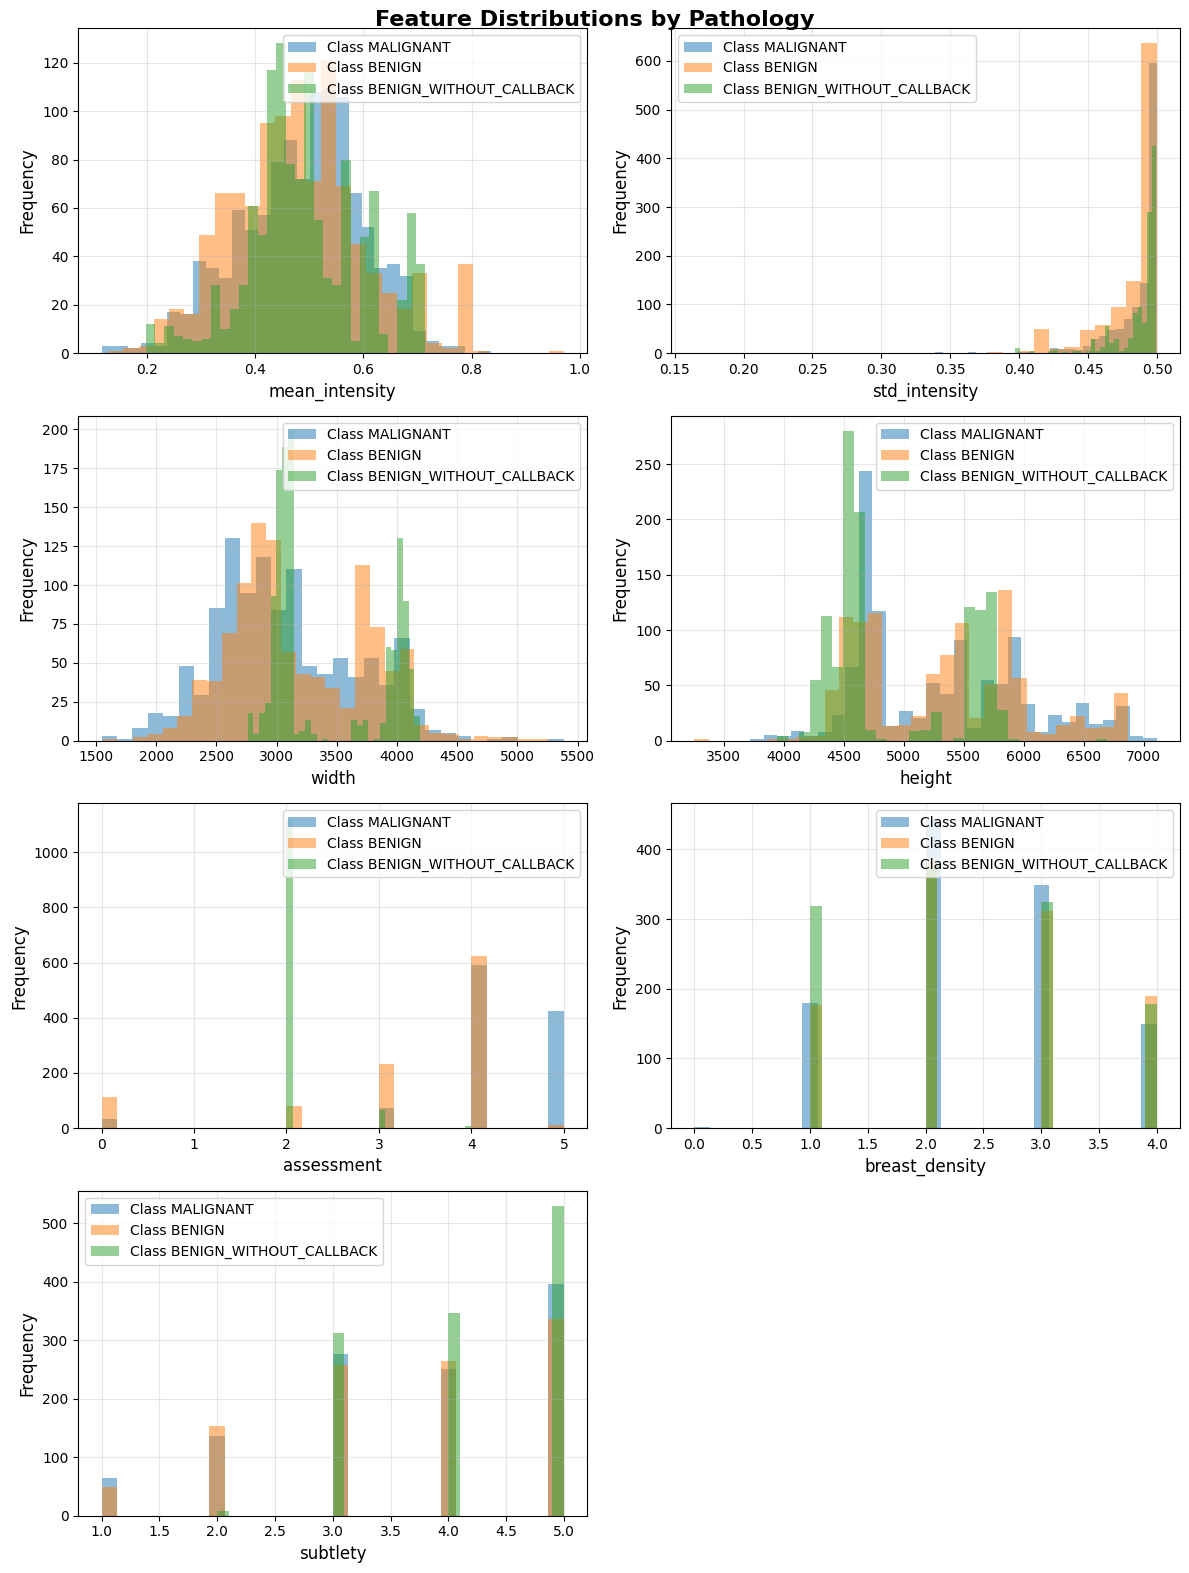


[INFO] Feature statistics:
       mean_intensity  std_intensity        width       height   assessment  \
count     3381.000000    3381.000000  3381.000000  3381.000000  3381.000000   
mean         0.487652       0.485392  3223.479148  5181.102928     3.132505   
std          0.114607       0.021142   558.491391   673.312898     1.266155   
min          0.116570       0.164411  1546.000000  3256.000000     0.000000   
25%          0.417374       0.482063  2872.000000  4600.000000     2.000000   
50%          0.487295       0.494227  3088.000000  5101.000000     3.000000   
75%          0.562378       0.498107  3744.000000  5704.000000     4.000000   
max          0.970453       0.499855  5386.000000  7111.000000     5.000000   

       breast_density     subtlety  
count     3381.000000  3381.000000  
mean         2.396037     3.845312  
std          0.974028     1.120030  
min          0.000000     1.000000  
25%          2.000000     3.000000  
50%          2.000000     4.000000  
7

In [25]:
# ===== FEATURE STATISTICS =====
print("\n" + "="*60)
print("FEATURE STATISTICS")
print("="*60)

import matplotlib.pyplot as plt
import seaborn as sns
import math

num_features = len(FEATURE_COLS)

cols = 2
rows = math.ceil(num_features / cols)

fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
axes = axes.flatten()

fig.suptitle('Feature Distributions by Pathology', fontsize=16, fontweight='bold')

for idx, feature in enumerate(FEATURE_COLS):
    ax = axes[idx]
    
    for pathology in train_df['pathology'].unique():
        subset = train_df[train_df['pathology'] == pathology][feature]
        ax.hist(subset, alpha=0.5, label=f'Class {pathology}', bins=30)
    
    ax.set_xlabel(feature, fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)

for ax in axes[num_features:]:
    ax.axis('off')

plt.tight_layout()
plt.savefig(f"feature_distributions_{corr_id}.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n[INFO] Feature statistics:")
print(train_df[FEATURE_COLS].describe())